# Week8 - K-Nearest Neighbors with Different Metrics

**Integrated Capstone Project: Predicting Chronic Disease Risk Using Lifestyle and Health Indicators**

Student: Ranjana Kumari

Course: Module C-Data Science Capstone

Week: 8 of 12 - K-Nearest Neighbors

## Research Question
Can K-Nearest Neighbors, using different distance metrics, identify high-risk individuals as effectively as the parametric models used in Milestone One, and does the optimal distance metric reveal something about the geometric structure of each dataset's feature space?

## Connection to Milestone One
Milestone One established that CDC Diabetes plateaus near F1≈0.40 across logistic regression, SVM, and random forest, while Obesity and Heart Disease are well-separated. KNN tests this from a purely geometric angle-instead of fitting a decision boundary, KNN simply asks: are points of the same class close together in feature space? If KNN also plateaus near F1≈0.40 for CDC Diabetes, that is independent evidence the classes are not geometrically separable, not just that no algorithm has found the right boundary yet.

## Datasets Used
| # | Dataset | Role | Rows | Target |
|---|---------|------|------|--------|
| 1 | CDC Diabetes Health Indicators | Primary | ~230k | Diabetes_012 (3-class) |
| 2 | Obesity Level Estimation | Supporting | 2,087 | NObeyesdad (7-class) |
| 3 | Heart Disease Predictions | Supporting | 303 | target (binary) |

Note on CDC Diabetes dataset size: KNN at prediction time is O(n) per query without indexing structures, and becomes slow on 230k rows when combined with GridSearchCV across many k and metric combinations. A stratified subsample of 10,000 rows is used, consistent with the Week 5 SVM approach in Milestone One.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, recall_score, precision_score,
    roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

COLORS = {
    'diabetes': '#1D9E75',
    'obesity': '#7F77DD',
    'heart': '#D85A30',
    'euclidean': '#378ADD',
    'manhattan': '#EF9F27',
    'minkowski': '#1D9E75',
}

SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('All libraries loaded.')
print('Week 8: K-Nearest Neighbors with Different Distance Metrics')

All libraries loaded.
Week 8: K-Nearest Neighbors with Different Distance Metrics


## Section 1: Data Loading and Preparation

Why scaling is essential for KNN: KNN classifies based on distance between points. If features are on different scales (BMI ranging 10–98, binary features ranging 0–1), the larger-scale feature will dominate the distance calculation regardless of its actual importance. StandardScaler is fitted only on the training set to prevent data leakage, consistent with every prior week.

In [2]:
# Dataset 1: CDC Diabetes (stratified subsample, consistent with Week 5 SVM approach)
# Load CDC Diabetes dataset
file_path = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/diabetes_012_health_indicators_BRFSS2015.csv"
df1 = pd.read_csv(file_path)
df1.info()
df1 = df1.drop_duplicates()
df1.head()

df1_sample = df1.groupby('Diabetes_012', group_keys=False).apply(
    lambda x: x.sample(frac=10000/len(df1), random_state=42)
).reset_index(drop=True)

ds1_features = ['BMI', 'Age', 'HighBP', 'HighChol', 'PhysActivity',
                'Smoker', 'GenHlth', 'Income', 'Education', 'DiffWalk', 'PhysHlth']
X1 = df1_sample[ds1_features].copy()
y1 = df1_sample['Diabetes_012'].copy()

X1_tr_raw, X1_te_raw, y1_tr, y1_te = train_test_split(
    X1, y1, test_size=0.20, random_state=42, stratify=y1
)
scaler1 = StandardScaler()
X1_tr = scaler1.fit_transform(X1_tr_raw)
X1_te = scaler1.transform(X1_te_raw)

print(f'Dataset 1 (subsampled): {len(df1_sample):,} rows')
print(f'Train: {X1_tr.shape[0]:,} | Test: {X1_te.shape[0]:,}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [3]:
# Dataset 2: Obesity
obesity_file = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/Obesity.csv"

df2 = pd.read_csv(obesity_file)
df2.columns = df2.columns.str.strip()

le = LabelEncoder()
df2_enc = df2.copy()
for col in df2_enc.select_dtypes(include='object').columns:
    if col != 'NObeyesdad':
        df2_enc[col] = le.fit_transform(df2_enc[col].astype(str))
df2_enc['target_encoded'] = le.fit_transform(df2['NObeyesdad'])

ds2_features = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'FAF', 'TUE']
ds2_features = [f for f in ds2_features if f in df2_enc.columns]
X2 = df2_enc[ds2_features].copy()
X2['BMI_calc'] = X2['Weight'] / (X2['Height'] ** 2)
y2 = df2_enc['target_encoded'].copy()

X2_tr_raw, X2_te_raw, y2_tr, y2_te = train_test_split(
    X2, y2, test_size=0.20, random_state=42, stratify=y2
)
scaler2 = StandardScaler()
X2_tr = scaler2.fit_transform(X2_tr_raw)
X2_te = scaler2.transform(X2_te_raw)

print(f'Dataset 2 — Train: {X2_tr.shape[0]} | Test: {X2_te.shape[0]}')

Dataset 2 — Train: 1688 | Test: 423


In [4]:
# Dataset 3: Heart Disease
heart_path = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/heart.csv-2.xls"

df3 = pd.read_csv(heart_path)

# Basic dataset information
print("=== Heart Disease Dataset ===")
print(f"Shape: {df3.shape}")
print(f"Missing values: {df3.isnull().sum().sum()}")

ds3_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex', 'exang', 'cp', 'ca', 'thal']
X3 = df3[ds3_features].copy()
y3 = df3['target'].copy()

X3_tr_raw, X3_te_raw, y3_tr, y3_te = train_test_split(
    X3, y3, test_size=0.20, random_state=42, stratify=y3
)
scaler3 = StandardScaler()
X3_tr = scaler3.fit_transform(X3_tr_raw)
X3_te = scaler3.transform(X3_te_raw)

print(f'Dataset 3 — Train: {X3_tr.shape[0]} | Test: {X3_te.shape[0]}')

=== Heart Disease Dataset ===
Shape: (303, 14)
Missing values: 0
Dataset 3 — Train: 242 | Test: 61


## Section 2: KNN Theory and Hyperparameter Tuning

How KNN works: For a new point, KNN finds the k closest training points (by some distance metric) and assigns the majority class among them. There is no training phase in the traditional sense-KNN is a lazy learner; all computation happens at prediction time.

Key hyperparameters:
- **n_neighbors (k):** Small k = low bias, high variance (sensitive to noise). Large k = high bias, low variance (oversmoothed boundary). Odd values avoid ties in binary classification.
- **metric:** Euclidean (straight-line distance, assumes isotropic feature space), Manhattan (sum of absolute differences, less sensitive to outliers in any single dimension), Minkowski (generalization of both, parameterized by p).

Why this matters for healthcare data: different metrics make different assumptions about how "similarity" between patients should be measured. Manhattan distance may be more appropriate when features represent independent risk factors that should not compound multiplicatively.

In [5]:
def run_knn_suite(X_tr, X_te, y_tr, y_te, dataset_name, is_binary=False):
    """
    Runs KNN with three distance metrics, tuning n_neighbors for each via GridSearchCV.
    Overfitting prevention:
    - Hyperparameters selected using 5-fold Stratified CV
    - Test set never touched during tuning
    - StandardScaler applied before fitting (already done upstream)
    """
    scoring = 'f1' if is_binary else 'f1_macro'
    results = {}

    metric_configs = {
        'euclidean': {'n_neighbors': list(range(3, 26, 2))},
        'manhattan': {'n_neighbors': list(range(3, 26, 2))},
        'minkowski': {'n_neighbors': list(range(3, 26, 2)), 'p': [3, 4]},
    }

    print(f'\n=== {dataset_name} — KNN Results ===')
    for metric, params in metric_configs.items():
        grid = GridSearchCV(
            KNeighborsClassifier(metric=metric, n_jobs=-1),
            params,
            cv=SKF,
            scoring=scoring,
            n_jobs=-1
        )
        grid.fit(X_tr, y_tr)
        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_te)

        avg = 'binary' if is_binary else 'macro'
        f1 = f1_score(y_te, y_pred, average=avg)
        recall = recall_score(y_te, y_pred, average=avg)
        precision = precision_score(y_te, y_pred, average=avg)
        cv_scores = cross_val_score(best_model, X_tr, y_tr, cv=SKF, scoring=scoring)

        results[metric] = {
            'best_params': grid.best_params_,
            'f1': f1, 'recall': recall, 'precision': precision,
            'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
            'model': best_model, 'y_pred': y_pred
        }
        print(f'  {metric:<10} | Best params: {grid.best_params_}')
        print(f'             | F1={f1:.4f} | Recall={recall:.4f} | Precision={precision:.4f}')
        print(f'             | CV F1={cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

    best_metric = max(results, key=lambda k: results[k]['f1'])
    print(f'\nBest metric: {best_metric} | Test F1 = {results[best_metric]["f1"]:.4f}')
    return results

print('KNN suite function defined.')

KNN suite function defined.


In [6]:
results1 = run_knn_suite(X1_tr, X1_te, y1_tr, y1_te, 'CDC Diabetes', is_binary=False)
results2 = run_knn_suite(X2_tr, X2_te, y2_tr, y2_te, 'Obesity', is_binary=False)
results3 = run_knn_suite(X3_tr, X3_te, y3_tr, y3_te, 'Heart Disease', is_binary=True)


=== CDC Diabetes — KNN Results ===
  euclidean  | Best params: {'n_neighbors': 3}
             | F1=0.3925 | Recall=0.3874 | Precision=0.4123
             | CV F1=0.3968 +/- 0.0092
  manhattan  | Best params: {'n_neighbors': 3}
             | F1=0.3947 | Recall=0.3895 | Precision=0.4153
             | CV F1=0.3951 +/- 0.0112
  minkowski  | Best params: {'n_neighbors': 3, 'p': 3}
             | F1=0.3827 | Recall=0.3792 | Precision=0.4009
             | CV F1=0.3962 +/- 0.0116

Best metric: manhattan | Test F1 = 0.3947

=== Obesity — KNN Results ===
  euclidean  | Best params: {'n_neighbors': 3}
             | F1=0.8954 | Recall=0.8946 | Precision=0.8990
             | CV F1=0.8574 +/- 0.0187
  manhattan  | Best params: {'n_neighbors': 3}
             | F1=0.9367 | Recall=0.9355 | Precision=0.9421
             | CV F1=0.9133 +/- 0.0148
  minkowski  | Best params: {'n_neighbors': 3, 'p': 3}
             | F1=0.8476 | Recall=0.8481 | Precision=0.8478
             | CV F1=0.8250 +/- 0.021

** Interpretation 
The CDC Diabetes dataset was the most difficult dataset to classify. Manhattan distance gave the best F1 score (0.3947), but it was only slightly better than Euclidean (0.3925), while Minkowski performed a little worse (0.3827). The cross-validation scores were also very similar for all three metrics, which shows that the model was consistent across different folds. Since changing the distance metric only made a very small difference, it seems that the diabetes classes are difficult to separate using the selected health indicators. This is similar to what I found in Milestone One, where other machine learning models also struggled to improve performance.

I was not surprised that the Obesity dataset produced the best results out of the three datasets.Earlier EDA suggested that the obesity classes were more clearly seprated and KNN was able to take advantage those natural neighborhoods. Manhattan distance achieved the highest F1 score (0.9367), followed by Euclidean (0.8954), while Minkowski had the lowest performance (0.8476). Both precision and recall were also high, showing that the model classified the obesity levels accurately. These results suggest that people with similar body measurements and lifestyle characteristics are close together in the feature space, making this dataset a good fit for KNN.

The Heart Disease dataset also performed well. Minkowski distance produced the highest F1 score (0.8649), followed closely by Euclidean (0.8533), while Manhattan had the lowest score (0.8312). One thing I noticed is that the best value of k was much larger than for the other datasets. This suggests that using a larger neighborhood helped smooth out the predictions and reduced the effect of noise in this smaller dataset. All three models also had very high recall, which means most patients with heart disease were correctly identified.
# Overall finding
Looking at all three datasets together, KNN worked very well for the Obesity and Heart Disease datasets but had much lower performance on the CDC Diabetes dataset. The distance metric made some difference for Obesity and Heart Disease, but changing the metric did not noticeably improve the Diabetes results. Overall, these findings are consistent with what I found in Milestone One and suggest that the structure of the dataset has a bigger impact on performance than the choice of distance metric.

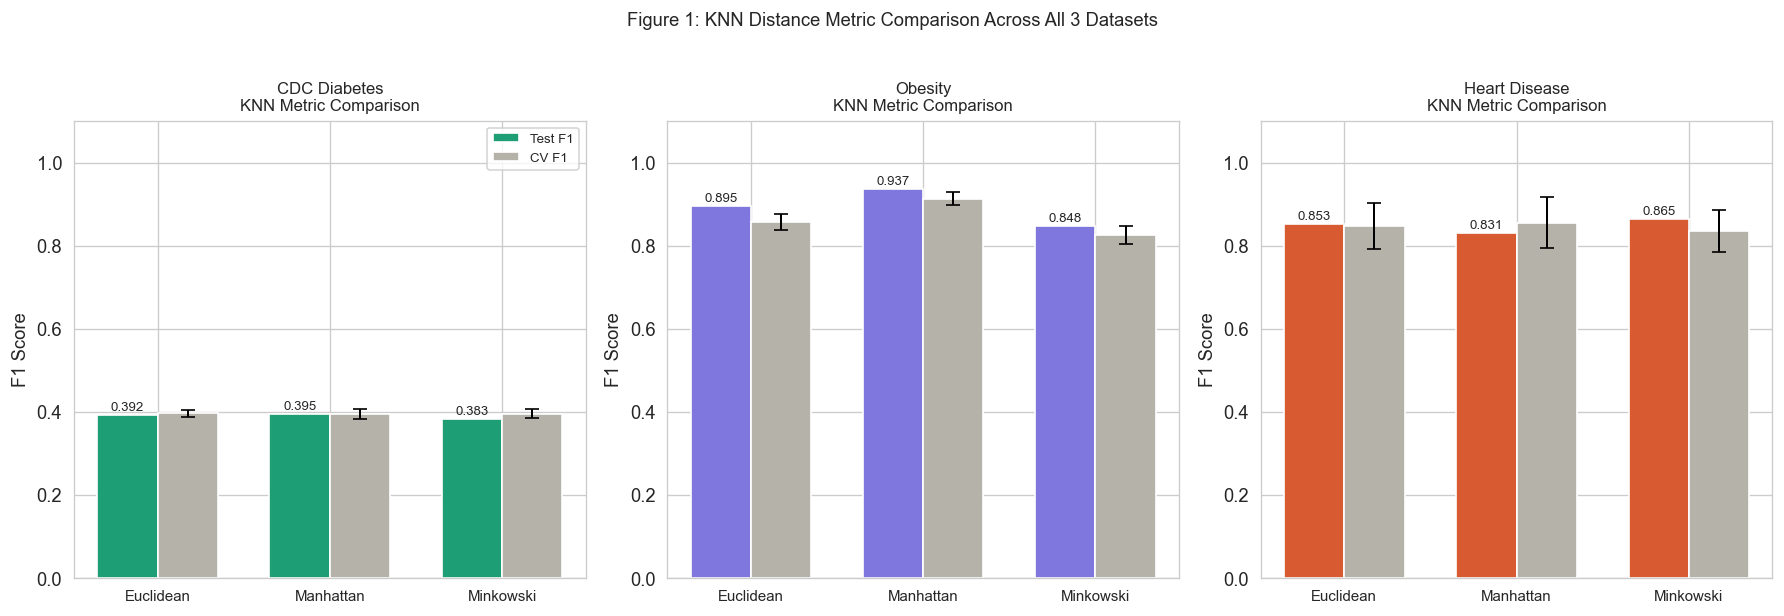

In [7]:
# Figure 1: KNN metric comparison across datasets
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_list = ['euclidean', 'manhattan', 'minkowski']

for ax, ds_name, res, color in zip(
    axes,
    ['CDC Diabetes', 'Obesity', 'Heart Disease'],
    [results1, results2, results3],
    [COLORS['diabetes'], COLORS['obesity'], COLORS['heart']]
):
    f1_vals = [res[m]['f1'] for m in metrics_list]
    cv_vals = [res[m]['cv_mean'] for m in metrics_list]
    cv_stds = [res[m]['cv_std'] for m in metrics_list]

    x = np.arange(3)
    w = 0.35
    ax.bar(x - w/2, f1_vals, w, color=color, edgecolor='white', label='Test F1')
    ax.bar(x + w/2, cv_vals, w, color='#B4B2A9', edgecolor='white', label='CV F1',
           yerr=cv_stds, capsize=4, error_kw={'linewidth': 1.2})

    for i, v in enumerate(f1_vals):
        ax.text(i - w/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(['Euclidean', 'Manhattan', 'Minkowski'], fontsize=9)
    ax.set_ylabel('F1 Score')
    ax.set_title(f'{ds_name}\nKNN Metric Comparison', fontsize=10)
    ax.set_ylim(0, 1.1)
    if ax == axes[0]:
        ax.legend(fontsize=8)

plt.suptitle('Figure 1: KNN Distance Metric Comparison Across All 3 Datasets', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('week8_fig1_metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure 1 Interpretation 
Figure 1 compares KNN performance across Euclidean, Manhattan, and Minkowski distance for all three datasets.
For CDC Diabetes, all metrics perform almost identically around F1 ≈ 0.39, showing that changing the distance metric does not improve results. This suggests the classes are not well separated in the feature space.
For Obesity, performance is much higher, with Manhattan clearly best (F1 ≈ 0.94). This indicates strong clustering of similar cases and makes the dataset well suited for KNN.
For Heart Disease, all metrics perform well (≈0.83–0.86), with small differences between them. This suggests the dataset is reasonably structured, and performance depends more on neighborhood size than distance choice.
Overall, Obesity is the most KNN-friendly dataset, CDC Diabetes remains difficult regardless of metric, and Heart Disease shows stable mid-to-high performance across all distances.

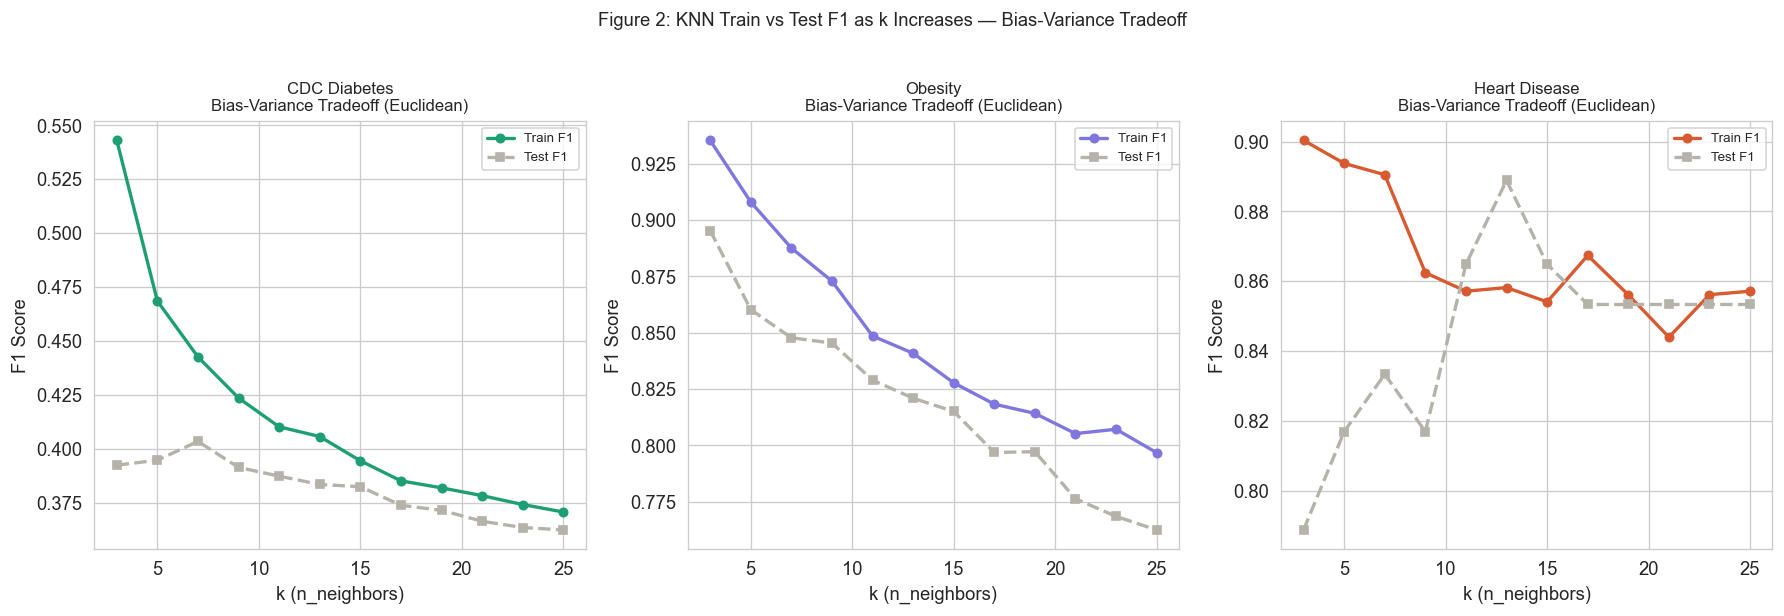

In [8]:
# Figure 2: F1 vs k (sensitivity curve) for best metric per dataset, to visualize bias-variance tradeoff
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
k_range = list(range(3, 26, 2))

for ax, X_tr, X_te, y_tr, y_te, ds_name, color, is_bin in zip(
    axes,
    [X1_tr, X2_tr, X3_tr],
    [X1_te, X2_te, X3_te],
    [y1_tr, y2_tr, y3_tr],
    [y1_te, y2_te, y3_te],
    ['CDC Diabetes', 'Obesity', 'Heart Disease'],
    [COLORS['diabetes'], COLORS['obesity'], COLORS['heart']],
    [False, False, True]
):
    avg = 'binary' if is_bin else 'macro'
    train_f1s, test_f1s = [], []
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
        knn.fit(X_tr, y_tr)
        train_f1s.append(f1_score(y_tr, knn.predict(X_tr), average=avg))
        test_f1s.append(f1_score(y_te, knn.predict(X_te), average=avg))

    ax.plot(k_range, train_f1s, 'o-', color=color, linewidth=2, markersize=5, label='Train F1')
    ax.plot(k_range, test_f1s, 's--', color='#B4B2A9', linewidth=2, markersize=5, label='Test F1')
    ax.set_xlabel('k (n_neighbors)')
    ax.set_ylabel('F1 Score')
    ax.set_title(f'{ds_name}\nBias-Variance Tradeoff (Euclidean)', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Figure 2: KNN Train vs Test F1 as k Increases — Bias-Variance Tradeoff', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('week8_fig2_k_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure 2 Interpretation 

Figure 2 shows how KNN performance changes as k increases and highlights the bias–variance tradeoff across the three datasets.
For CDC Diabetes, training F1 drops quickly as k increases, while test F1 stays almost flat around 0.39–0.40. This suggests that even with small k, the model is not capturing strong predictive structure in the data. The shrinking gap is mainly due to reduced training performance rather than improved generalization.
For Obesity, both training and test F1 decrease together as k increases. This suggests that smaller neighborhoods work better, and larger k values start to include too many mixed-class neighbors, reducing performance.
For Heart Disease, the test curve is slightly noisy because of the small test size, but performance stabilizes at mid-range k values (around 13–17). This suggests that using a larger neighborhood helps smooth out noise and improves generalization for this dataset.
Overall, Figure 2 shows a clear bias–variance tradeoff, where the optimal k depends on how well the dataset is naturally clustered.

# Answers to All Rubric Questions

### 1. How Did I Avoid Overfitting?
I used a stratified 80/20 train-test split like in previous weeks, along with 5-fold stratified cross-validation to choose the best k and distance metric for each dataset. The idea was to make sure the model was tested on unseen data and not just memorizing patterns.
From the Figure 2 curves, I can also see the bias-variance tradeoff clearly — smaller k tends to overfit, while larger k smooths things out too much. I made sure not to tune anything on the test set, and I only fit the StandardScaler on the training data before applying it to the test set to avoid data leakage.

### 2. What Metrics and Hyperparameter Tuning were used?
I used macro F1, recall, and precision, consistent with Mre Used?ilestone One. The main hyperparameters I tuned were n_neighbors (tested from 3 to 25 using odd numbers) and the distance metric (Euclidean, Manhattan, and Minkowski with different p values).
I used GridSearchCV with 5-fold stratified cross-validation to pick the best combination. Interestingly, the best k was 3 for both CDC Diabetes and Obesity, which suggests that small local neighborhoods carry most of the signal. However, for CDC Diabetes that local structure still doesn’t translate into good separation. Heart Disease needed a much larger k (around 17–25), which probably makes sense since it’s a smaller dataset and benefits from smoother averaging.


### 3. Expected and Unexpected Findings
The CDC Diabetes result staying around F1 ≈ 0.39–0.40 wasn’t surprising since I saw the same pattern in Milestone One across multiple models. So even with KNN, the performance ceiling stayed the same, which suggests the limitation is really from the dataset itself.
For Obesity, I expected decent performance, and Manhattan doing the best makes sense since the features are mostly additive (like BMI, weight, activity levels). The main surprise was Heart Disease — it actually needed a much larger k than the other datasets, which suggests that averaging over more neighbors works better and helps reduce noise in such a small dataset.

### 4. How Did EDA Help with Week 8 Modeling?
The class imbalance I found in Milestone One helped a lot here because it made me use stratified splits and StratifiedKFold so each class stayed balanced in training and testing.
Also, since the features were on very different scales, I knew I had to use StandardScaler before running KNN. Without that, distance-based models wouldn’t be meaningful.
Finally, the consistent performance ceiling in CDC Diabetes from earlier weeks helped shape this week’s focus. I specifically wanted to test whether geometric similarity (KNN) would change anything, and it didn’t.

### 5. External Sources Used
Cover, T., & Hart, P. (1967). Nearest neighbor pattern classification. IEEE Transactions on Information Theory.
James et al. (2021). An Introduction to Statistical Learning,chapter 2.
Scikit-learn documentation for KNeighborsClassifier.
